# Dealer Attention Engine: working prototype

**Case:** Which dealers need management attention?
**Companion document:** *Dealer Attention Engine: Data to Decision*

This notebook is the prototype. It runs the document's chain end to end, from raw dealer data to one
ranked action list per regional manager.

| Step | Section | Output |
|---|---|---|
| Parameters | 1 | Every number tagged Published, Derived, Contractual or Calibrated |
| 1. Data | 2 | 48 dealers x 24 months, every field named to the system it lives in |
| 2. Metrics | 3 | 16 metrics in four buckets; target achievement kept as low-weight context |
| 3. Signals | 4 | Level, trend and hard floors inside the peer cohort |
| 4. Diagnosis | 5 | 8 rules naming a likely cause; 6 archetypes; each routed to an owner |
| 5. Decision | 6 | Tier, then risk x value, cut to each regional manager's capacity |
| Demo | 7 | Dealer 112 on one page: flagged while its sales still look normal |
| Check | 8 | Does it catch what is really wrong, early, and spare what is not |
| Feedback | 9 | Visited dealers against an unvisited control group |

**Results on the planted test data (final month, section 8):** 15 of 18 planted problems are on a
visit list, with no healthy or market-limited dealer sent for a visit. Both regional managers' lists
are 4 of 4 genuine problems, every caught problem gets the right cause, and the median warning is
2 months before sales fall. Dealer 112 comes out exactly as in the document: cash stress, Tier 1,
rank 3 on the West list, owner the regional credit manager.

**How to run.** Top to bottom, in about 10 seconds. No external files, no internet. Needs `pandas`,
`numpy` and `matplotlib`, all preinstalled on Google Colab. One fixed random seed, so every number
reproduces.

**On the data.** Finance and inventory values are a labelled representative extract: the schema and
source systems are real, the values are not the client's. Market structure follows FADA and VAHAN
grain. Every threshold is tagged in the parameter register, and each placeholder names the
calibration question (Q1 to Q10 in the document) that replaces it.

In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
RNG = np.random.default_rng(20261004)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.3


## 1. The parameter register

Every number the engine uses is one of four kinds. There is no fifth.

- **Published:** an external figure, cited.
- **Derived:** arithmetic on published figures or on other parameters, working shown.
- **Contractual:** from the client's dealer agreement or financing terms. We ask for the document.
- **Calibrated:** the client sets the value; we supply the mechanism.

Anything marked *placeholder* waits on one of the document's ten calibration questions.

In [2]:
PARAMS = [
 # name, value, kind, what it sets / where it comes from
 ("fada_inventory_norm_days", 21, "Published",
  "FADA's recommended dealer stock. Sizes the industry excess only; never a flag."),
 ("nada_us_norm_days", "45-60", "Published",
  "NADA (US) guide. Listed only to show why US benchmarks are not imported."),
 ("value_per_car_inr", 997000, "Derived",
  "Rs 77,800 cr / 7.8 lakh cars, FADA Aug 2024. Before the Sept 2025 GST cut, so likely high today."),
 ("contribution_per_car_inr", 60000, "Calibrated",
  "Illustrative placeholder, not a validated floor. Order of magnitude only: Maruti FY26 net profit "
  "Rs 14,445 cr / 24.23 lakh cars. Net profit is not contribution; the client supplies it (Q8)."),
 ("brand_state_share", 0.33, "Calibrated",
  "The brand's PV share in this state. Set to match the extract (3 outlets a district, about 11% "
  "each). The client supplies the real figure."),
 ("stocking_norm_days", 45, "Contractual",
  "HARD FLOOR. Dealer agreement stocking norm. Placeholder until Q4, set above the Aug 2026 industry "
  "level (38-40 days) so the demo separates a dealer from the network-wide excess."),
 ("credit_period_days", 30, "Contractual",
  "HARD FLOOR. Credit period in the dealer agreement. Placeholder until Q3."),
 ("floorplan_limit_pct", 1.00, "Contractual",
  "HARD FLOOR. Sanctioned floor plan limit. Placeholder until Q5."),
 ("floorplan_near_limit_pct", 0.85, "Calibrated",
  "'Floor plan near limit' in the cash-stress rule, as a share of the sanctioned limit. Q5."),
 ("ageing_bucket_days", 60, "Contractual",
  "Ageing cut-off. Placeholder until the dealer agreement gives the funding terms (Q3)."),
 ("tier1_pct", 10, "Calibrated",
  "Worst n% of a cohort. Fires a signal; on any bucket it puts a dealer in Tier 1. Q1."),
 ("manager_capacity", 4, "Calibrated",
  "Dealers one regional manager can work in depth in a month (about one a week). Cuts each list. Q1."),
 ("trend_window_months", 3, "Calibrated",
  "Rolling window for trends. 'Up' means worse than the previous window. Q6."),
 ("persistence_months", 2, "Calibrated",
  "Months in a row before a wobble becomes a pattern. Q7."),
 ("warm_up_months", 14, "Derived",
  "No decisions before month 14: 3-month growth against last year needs 12 + 3 months of history."),
 ("min_cohort_size", 8, "Calibrated",
  "Below this, percentiles are unstable; the dealer falls back to a wider pool."),
 ("staff_exits_alert_6m", 4, "Calibrated",
  "Sales staff exits in 6 months that count as 'staff exits up'. Dealer-declared: a hint, never alone."),
 ("review_cycle_months", 3, "Calibrated",
  "Months between an action and its review. Q6."),
 ("share_of_buyers_lost", 0.50, "Calibrated",
  "Placeholder, Q8. Shown with 25% and 75% scenarios. It scales every dealer alike, so it moves the "
  "rupee figure, never the ranking."),
 ("service_contribution_per_job_inr", 4500, "Calibrated",
  "Contribution per service job (parts and labour). Placeholder, Q8."),
 ("w_target_in_demand", 0.5, "Calibrated",
  "Weight of target achievement inside Demand (each other demand metric 1.0). Context KPI, kept low."),
 ("w_finance", 0.35, "Calibrated", "Illustrative. The survival bucket, and it moves first. Refit on Q2."),
 ("w_inventory", 0.25, "Calibrated", "Illustrative. Refit on Q2."),
 ("w_demand", 0.25, "Calibrated", "Illustrative. Refit on Q2."),
 ("w_customer", 0.15, "Calibrated",
  "Illustrative. Lowest for immediate survival, but a leading signal: its worst decile still "
  "triggers Tier 1. Refit on Q2."),
]
register = pd.DataFrame(PARAMS, columns=["parameter", "value", "kind", "sets / sourced from"])
register["value"] = register["value"].astype(str)
P = {r[0]: r[1] for r in PARAMS}
with pd.option_context("display.max_colwidth", 200):
    display(register.set_index("parameter"))
print("By kind:", register.kind.value_counts().to_dict())

,value,kind,sets / sourced from
parameter,,,
fada_inventory_norm_days,21,Published,FADA's recommended dealer stock. Sizes the industry excess only; never a flag.
nada_us_norm_days,45-60,Published,NADA (US) guide. Listed only to show why US benchmarks are not imported.
value_per_car_inr,997000,Derived,"Rs 77,800 cr / 7.8 lakh cars, FADA Aug 2024. Before the Sept 2025 GST cut, so likely high today."
contribution_per_car_inr,60000,Calibrated,"Illustrative placeholder, not a validated floor. Order of magnitude only: Maruti FY26 net profit Rs 14,445 cr / 24.23 lakh cars. Net profit is not contribution; the client supplies it (Q8)."
brand_state_share,0.33,Calibrated,"The brand's PV share in this state. Set to match the extract (3 outlets a district, about 11% each). The client supplies the real figure."
stocking_norm_days,45,Contractual,"HARD FLOOR. Dealer agreement stocking norm. Placeholder until Q4, set above the Aug 2026 industry level (38-40 days) so the demo separates a dealer from the network-wide excess."
credit_period_days,30,Contractual,HARD FLOOR. Credit period in the dealer agreement. Placeholder until Q3.
floorplan_limit_pct,1.0,Contractual,HARD FLOOR. Sanctioned floor plan limit. Placeholder until Q5.
floorplan_near_limit_pct,0.85,Calibrated,"'Floor plan near limit' in the cash-stress rule, as a share of the sanctioned limit. Q5."


By kind: {'Calibrated': 17, 'Contractual': 4, 'Published': 2, 'Derived': 2}


## 2. Step 1: Data

Rule from the document: **every field names the system it already lives in. No source, no field.**

Nothing below needs new collection. Tier 3 fields (mystery shopping, dealer P&L, competitor street
prices) are deliberately absent: the client cannot hand them over on day one.

The generator plants six dealer behaviours on purpose, so section 8 can check whether the engine
finds what is really there. The engine never sees the planted truth.

**Dealer 112** is the document's worked example: a Nashik dealer whose cash stress starts in month
19, so in the final month it is building while retail still looks normal. Its last three months
carry the document's exact figures.

Two simplifications, stated so nobody has to find them: each outlet carries its own market series
(in production this is one VAHAN series per RTO, shared by its outlets), and closing stock is drawn
each month rather than rolled forward from billing and retail (in production DMS stock is the record).

In [3]:
SCHEMA = [
 ("retail_units",            "DMS", "Tier 1", "Cars delivered to customers"),
 ("target_units",            "Sales planning", "Tier 1", "Monthly target"),
 ("enquiries",               "DMS / CRM", "Tier 1", "Walk-ins, calls, digital leads"),
 ("wholesale_units",         "OEM ERP (SAP)", "Tier 1", "Cars billed to the dealer"),
 ("closing_stock_units",     "DMS stock", "Tier 1", "Unsold cars at month end"),
 ("stock_over_60d",          "DMS stock, billing date per VIN", "Tier 1", "Aged units"),
 ("stock_mix_suv_pct",       "DMS stock", "Tier 1", "Share of stock that is SUV"),
 ("receivable_total",        "OEM ERP finance", "Tier 1", "Total owed by dealer"),
 ("receivable_overdue",      "OEM ERP finance", "Tier 1", "Past the credit period"),
 ("overdue_days_weighted",   "OEM ERP finance", "Tier 1", "Amount-weighted days past due"),
 ("floorplan_outstanding",   "Financing bank", "Tier 1", "Drawn on the floor plan"),
 ("floorplan_limit",         "Financing bank", "Tier 1", "Sanctioned limit"),
 ("cheque_bounces",          "OEM ERP finance", "Tier 1", "Dishonour events"),
 ("sales_complaints",        "Call centre / CRM", "Tier 1", "Complaints about buying"),
 ("service_complaints",      "Call centre / CRM", "Tier 1", "Complaints about servicing"),
 ("complaint_days_median",   "Call centre / CRM", "Tier 1", "Median days to close"),
 ("complaints_escalated",    "Call centre / CRM", "Tier 1", "Escalated to the OEM"),
 ("service_jobs",            "DMS service", "Tier 1", "Cars serviced"),
 ("returning_customers",     "DMS service", "Tier 1", "Of cars sold 12-36m ago, came back"),
 ("sold_12_36m_ago",         "DMS retail history", "Tier 1", "Denominator for retention"),
 ("discount_total_inr",      "DMS retail", "Tier 1", "Total discount given"),
 ("ex_showroom_total_inr",   "DMS retail", "Tier 1", "List value of cars sold"),
 ("sales_staff_exits",       "Dealer portal", "Tier 1", "Dealer-declared. Diagnosis only."),
 ("district_registrations",  "VAHAN (MoRTH)", "Tier 2", "All makers in the RTO. The denominator."),
 ("district_mix_suv_pct",    "VAHAN (MoRTH)", "Tier 2", "What the district actually buys"),
 ("brand_outlets_district",  "Network management", "Tier 1", "Same-brand outlets in the district"),
 ("region",                  "Network management", "Tier 1", "Regional manager's territory"),
]
schema = pd.DataFrame(SCHEMA, columns=["field", "source_system", "tier", "what it is"])
display(schema.set_index("field"))
print(f"{len(schema)} fields. Tier 1 (already in the OEM): {(schema.tier == 'Tier 1').sum()}"
      f" | Tier 2 (public): {(schema.tier == 'Tier 2').sum()} | Tier 3 (needs new collection): 0")

,source_system,tier,what it is
field,,,
retail_units,DMS,Tier 1,Cars delivered to customers
target_units,Sales planning,Tier 1,Monthly target
enquiries,DMS / CRM,Tier 1,"Walk-ins, calls, digital leads"
wholesale_units,OEM ERP (SAP),Tier 1,Cars billed to the dealer
closing_stock_units,DMS stock,Tier 1,Unsold cars at month end
stock_over_60d,"DMS stock, billing date per VIN",Tier 1,Aged units
stock_mix_suv_pct,DMS stock,Tier 1,Share of stock that is SUV
receivable_total,OEM ERP finance,Tier 1,Total owed by dealer
receivable_overdue,OEM ERP finance,Tier 1,Past the credit period


27 fields. Tier 1 (already in the OEM): 25 | Tier 2 (public): 2 | Tier 3 (needs new collection): 0


In [4]:
N_MONTHS = 24
MONTHS = pd.period_range("2024-10", periods=N_MONTHS, freq="M").astype(str).tolist()

# Maharashtra RTOs. Monthly PV registrations are the VAHAN grain: all makers in that district.
DISTRICTS = [("Pune","large",4200),("Mumbai Suburban","large",4600),("Thane","large",3800),
             ("Nagpur","large",2600),("Nashik","mid",1800),("Aurangabad","mid",1500),
             ("Solapur","mid",1200),("Kolhapur","mid",1350),("Amravati","mid",1050),
             ("Jalgaon","small",720),("Satara","small",640),("Latur","small",560),
             ("Chandrapur","small",600),("Nanded","small",580),("Ratnagiri","small",470),
             ("Dhule","small",520)]
# Two regional managers, each owning one territory
WEST = {"Pune","Mumbai Suburban","Thane","Nashik","Kolhapur","Satara","Ratnagiri","Solapur"}
REGION = {d: ("West" if d in WEST else "East") for d, _, _ in DISTRICTS}

# Planted behaviour. The engine never sees this column.
PLAN = (["silent_sinker_cash"]*4 + ["silent_sinker_push"]*4 + ["silent_sinker_margin"]*3
        + ["silent_sinker_brand"]*3 + ["execution_gap"]*4 + ["market_limited"]*5 + ["healthy"]*25)

def ramp(t, start, span, peak):
    return 0.0 if t < start else peak * min(1.0, (t - start) / span)

def make_master():
    truths = [PLAN[i] for i in RNG.permutation(len(PLAN))]
    rows = []
    for i, truth in enumerate(truths):
        d, band, reg = DISTRICTS[i % len(DISTRICTS)]
        rows.append(dict(dealer_id=f"D{101+i}", dealer_name=f"{d} Motors {1 + i//len(DISTRICTS)}",
                         district=d, market_band=band, district_reg_base=reg,
                         outlet_type=str(RNG.choice(["3S","Sales only"], p=[.75,.25])),
                         years_with_brand=int(RNG.integers(3, 22)),
                         brand_outlets_district=int(RNG.integers(1, 4)),   # replaced by a count below
                         truth=truth))
    return pd.DataFrame(rows)

def dealer_rows(d, rng, shift=0):
    """One dealer's 24 months. `shift` delays the planted problem by that many months."""
    out = []
    t0 = d.truth
    share0 = max(.05, float(rng.normal(.11, .013)))      # of district registrations
    conv0  = float(rng.normal(.145, .013))
    delay0 = float(rng.normal(11, 2.5))
    fp0    = float(rng.normal(.60, .06))
    age0   = float(rng.normal(.13, .025))
    inv0   = float(rng.normal(34, 4))
    scpl0  = float(rng.normal(2.2, .5))                  # sales complaints / 1000
    vcpl0  = float(rng.normal(5.0, 1.1))                 # service complaints / 1000 jobs
    ret0   = float(rng.normal(.64, .045))
    disc0  = float(rng.normal(.042, .005))               # discount as % of ex-showroom
    res0   = float(rng.normal(5.5, 1.2))                 # median days to close
    mixd   = float(rng.normal(0, .03))                   # dealer's stock mix bias vs district
    for t, month in enumerate(MONTHS):
        u = t - shift                                    # time on the planted problem's clock
        season   = 1 + .30*np.sin((t+1)*2*np.pi/12 - 1.1)
        reg_tr   = 1 + .004*t
        if t0 == "market_limited":
            reg_tr *= 1 - ramp(u, 6, 12, .34)            # the market itself is shrinking
        dreg = d.district_reg_base * season * reg_tr * rng.normal(1, .045)

        share, conv, delay, fp, age, inv = share0, conv0, delay0, fp0, age0, inv0
        scpl, vcpl, ret, disc, res, mix  = scpl0, vcpl0, ret0, disc0, res0, mixd
        push, exits, bounce, esc = 1.0, rng.poisson(.4), 0, .05

        if t0 == "silent_sinker_cash":        # cash stress from m12, sales only fall from m18
            delay += ramp(u,12,6,30); fp += ramp(u,12,6,.38); bounce = rng.poisson(ramp(u,14,5,1.1))
            age   += ramp(u,13,6,.15); inv += ramp(u,13,6,14); share *= 1 - ramp(u,18,5,.28)
        elif t0 == "silent_sinker_push":      # billed in, not sold out
            push = 1 + ramp(u,10,6,.42); inv += ramp(u,10,7,26); age += ramp(u,10,7,.23)
            mix += ramp(u,11,7,.17);     share *= 1 - ramp(u,19,5,.12)
        elif t0 == "silent_sinker_margin":    # buying volume
            disc *= 1 + ramp(u,11,8,.85);  share *= 1 + ramp(u,11,8,.05)
        elif t0 == "silent_sinker_brand":     # customers leaving quietly
            scpl *= 1 + ramp(u,11,7,1.5); vcpl *= 1 + ramp(u,11,7,1.3)
            ret  *= 1 - ramp(u,11,8,.30); res *= 1 + ramp(u,12,7,1.0)
            esc  += ramp(u,12,7,.22);     share *= 1 - ramp(u,18,6,.15)
        elif t0 == "execution_gap":
            conv *= 1 - ramp(u,13,6,.34); exits = rng.poisson(.4 + ramp(u,12,5,1.9))
            share *= 1 - ramp(u,15,7,.20)
        elif t0 == "market_limited":
            share *= 1.07                                # beats a shrinking market

        retail = max(4, int(dreg * share * rng.normal(1, .055)))
        enq    = max(retail+3, int(retail / max(.05, conv) * rng.normal(1, .045)))
        whole  = max(1, int(retail * push * rng.normal(1, .07)))
        invd   = max(8, inv * rng.normal(1, .055))
        stock  = max(3, int(retail/30 * invd))
        over60 = int(stock * min(.85, max(.01, age * rng.normal(1, .11))))
        exshow = retail * P["value_per_car_inr"]
        recv   = exshow * rng.normal(.34, .035)
        dly    = max(0., delay * rng.normal(1, .09))
        odr    = min(.9, max(0., (dly - 7)/60)) * rng.normal(1, .09)
        fplim  = exshow * 1.5
        sold   = max(60, int(retail * 22 * rng.normal(1, .045)))
        jobs   = max(20, int(sold * max(.15, min(.95, ret * rng.normal(1, .035)))))
        out.append(dict(
            dealer_id=d.dealer_id, month=month, month_index=t,
            retail_units=retail, target_units=max(5, int(retail*rng.normal(1.06,.09))),
            enquiries=enq, wholesale_units=whole,
            closing_stock_units=stock, stock_over_60d=over60,
            stock_mix_suv_pct=float(np.clip(.38 + mix + rng.normal(0,.02), .05, .95)),
            receivable_total=round(recv), receivable_overdue=round(recv*max(0.,odr)),
            overdue_days_weighted=round(dly,1),
            floorplan_outstanding=round(fplim*min(1.25,max(.1, fp*rng.normal(1,.04)))),
            floorplan_limit=round(fplim), cheque_bounces=int(bounce),
            sales_complaints=int(rng.poisson(max(.1, scpl*retail/1000*9))),
            service_complaints=int(rng.poisson(max(.1, vcpl*jobs/1000*2.5))),
            complaint_days_median=round(max(1., res*rng.normal(1,.12)),1),
            complaints_escalated=int(rng.poisson(max(.05, esc*6))),
            service_jobs=jobs, returning_customers=int(sold*max(.15,min(.95,ret*rng.normal(1,.035)))),
            sold_12_36m_ago=sold,
            discount_total_inr=round(exshow*max(.005, disc*rng.normal(1,.07))),
            ex_showroom_total_inr=round(exshow),
            sales_staff_exits=int(exits),
            district_registrations=int(dreg),
            district_mix_suv_pct=float(np.clip(.38 + rng.normal(0,.015), .05, .95)),
            brand_outlets_district=int(d.brand_outlets_district)))
    return out

def make_monthly(master):
    return pd.DataFrame([row for _, d in master.iterrows() for row in dealer_rows(d, RNG)])

master = make_master()
# Dealer 112 is the document's worked example: a Nashik dealer whose cash stress is building now,
# while its retail still looks normal. It is placed in Nashik before the monthly data is drawn.
D112 = "D112"
D112_SHIFT = 7          # its cash stress starts in month 19, not 12, so its sales have not fallen yet
master.loc[master.dealer_id == D112, ["dealer_name", "district", "market_band", "district_reg_base"]] = \
    ["Nashik Motors (Dealer 112)", "Nashik", "mid", 1800]
# Same-brand outlets per district are counted from the network itself, not drawn
master["brand_outlets_district"] = master.groupby("district").dealer_id.transform("count")
master["region"] = master.district.map(REGION)
monthly = make_monthly(master)
# Redraw Dealer 112 on its own random stream with the later start, so no other dealer's data changes
d112_row = master.loc[master.dealer_id == D112].iloc[0]
monthly = pd.concat([monthly[monthly.dealer_id != D112],
                     pd.DataFrame(dealer_rows(d112_row, np.random.default_rng(113), shift=D112_SHIFT))],
                    ignore_index=True)

print(f"{master.dealer_id.nunique()} dealers x {monthly.month.nunique()} months = {len(monthly):,} rows")
print("Dealers per region:", master.region.value_counts().to_dict())
print("\nPlanted behaviour (hidden from the engine):")
print(master.truth.value_counts().to_string())

48 dealers x 24 months = 1,152 rows
Dealers per region: {'West': 25, 'East': 23}

Planted behaviour (hidden from the engine):
truth
healthy                 25
market_limited           5
execution_gap            4
silent_sinker_cash       4
silent_sinker_push       4
silent_sinker_margin     3
silent_sinker_brand      3


In [5]:
# Dealer 112's last three months are set to the document's figures. They reconcile:
# closing stock = opening stock + billed - retailed, so 230 -> 270 -> 310 at +40 a month.
last_t = N_MONTHS - 1
DOC_112 = {   # months before the last: values from the document's worked example
    2: dict(retail_units=160, wholesale_units=200, closing_stock_units=230, stock_over_60d=55,
            overdue_days_weighted=16.0, receivable_overdue=12_000_000),
    1: dict(retail_units=160, wholesale_units=200, closing_stock_units=270, stock_over_60d=74,
            overdue_days_weighted=25.0, receivable_overdue=15_000_000),
    0: dict(retail_units=160, wholesale_units=200, closing_stock_units=310, stock_over_60d=96,
            overdue_days_weighted=34.0, receivable_overdue=18_000_000),
}
is112 = monthly.dealer_id.eq(D112)
for back, vals in DOC_112.items():
    row = is112 & monthly.month_index.eq(last_t - back)
    # enquiries and target move with retail, so conversion and target achievement keep their level
    scale = vals["retail_units"] / float(monthly.loc[row, "retail_units"].iloc[0])
    for col in ["enquiries", "target_units"]:
        monthly.loc[row, col] = round(float(monthly.loc[row, col].iloc[0]) * scale)
    for col, v in vals.items():
        monthly.loc[row, col] = v
row = is112 & monthly.month_index.eq(last_t)
monthly.loc[row, "floorplan_outstanding"] = round(float(monthly.loc[row, "floorplan_limit"].iloc[0]) * 0.94)

cols = ["month","retail_units","wholesale_units","closing_stock_units","stock_over_60d",
        "overdue_days_weighted","receivable_overdue","floorplan_outstanding","floorplan_limit"]
print("Dealer 112, raw inputs, last three months:")
print(monthly[is112].tail(3)[cols].to_string(index=False))

Dealer 112, raw inputs, last three months:
  month  retail_units  wholesale_units  closing_stock_units  stock_over_60d  overdue_days_weighted  receivable_overdue  floorplan_outstanding  floorplan_limit
2026-07           160              200                  230              55                  16.00            12000000              155456353        264703500
2026-08           160              200                  270              74                  25.00            15000000              181292106        288631500
2026-09           160              200                  310              96                  34.00            18000000              244603980        260217000


## 3. Step 2: Metrics

Raw fields become **16 metrics in four buckets.** Target achievement stays as a **context KPI with a
low weight inside Demand**, so it cannot dominate the early-warning score, and it never fires a
signal on its own.

Three metrics combine two parts that cannot be added (a percentage and a count), so each part is
ranked separately in Step 3 and then averaged: **credit stress**, **complaint rate** and
**resolution speed**.

Three names carry their assumption:

- **Potential capture (equal-share proxy).** Version 1 assumes each same-brand outlet in a district
  has equal opportunity; version 2 would use catchment or lead data. The district denominator is
  RTO-based, so it is a directional benchmark, not true catchment.
- **Service retention index.** Read only against peers, as vehicle mix and geography also move it.
- **Billing-retail gap.** Not "push" on its own: festive stocking, launches and transit also widen it.
  "Stock pushed" is diagnosed only when stock days and ageing are up too.

Diagnosis-only inputs, never scored: staff exits, and the enquiry, retail, share and district
registration trends.

In [6]:
df = (monthly.merge(master[["dealer_id","dealer_name","district","region","market_band",
                            "outlet_type","years_with_brand"]], on="dealer_id")
      .sort_values(["dealer_id","month_index"]).reset_index(drop=True))

def per_dealer(col, fn):
    return df.groupby("dealer_id", sort=False)[col].transform(fn)

df["retail_3m"]    = per_dealer("retail_units",    lambda s: s.rolling(3, min_periods=1).sum())
df["wholesale_3m"] = per_dealer("wholesale_units", lambda s: s.rolling(3, min_periods=1).sum())
df["jobs_3m"]      = per_dealer("service_jobs",    lambda s: s.rolling(3, min_periods=1).sum())
df["retail_3m_ly"] = per_dealer("retail_3m",       lambda s: s.shift(12))
for src, name in [("retail_units","retail_12m"), ("service_jobs","jobs_12m"),
                  ("sales_complaints","scompl_12m"), ("service_complaints","vcompl_12m")]:
    df[name] = per_dealer(src, lambda s: s.rolling(12, min_periods=3).sum())

# ---------------- DEMAND ----------------
df["target_achievement"] = df.retail_units / df.target_units                  # context KPI, low weight
df["growth"]             = df.retail_3m / df.retail_3m_ly
df["district_share"]     = df.retail_units / df.district_registrations
df["potential_capture"]  = df.retail_units / (df.district_registrations * P["brand_state_share"]
                                              / df.brand_outlets_district)   # equal-share proxy
df["funnel_conversion"]  = df.retail_units / df.enquiries
df["discount_intensity"] = df.discount_total_inr / df.ex_showroom_total_inr

# ---------------- INVENTORY ----------------
df["inventory_days"]     = df.closing_stock_units / (df.retail_3m / 90)
df["ageing"]             = df.stock_over_60d / df.closing_stock_units
df["mix_mismatch"]       = (df.stock_mix_suv_pct - df.district_mix_suv_pct).abs()
df["billing_retail_gap"] = (df.wholesale_3m - df.retail_3m) / df.retail_3m

# ---------------- FINANCE ----------------
df["weighted_payment_delay"] = df.overdue_days_weighted
df["overdue_ratio"]          = df.receivable_overdue / df.receivable_total
df["cs_floorplan_use"]       = df.floorplan_outstanding / df.floorplan_limit      # credit stress, part a
df["cs_bounces"]             = per_dealer("cheque_bounces", lambda s: s.rolling(6, min_periods=1).sum())

# ---------------- CUSTOMER ----------------
df["cr_sales_per_1000"]       = df.scompl_12m / df.retail_12m * 1000             # complaint rate, part a
df["cr_service_per_1000"]     = df.vcompl_12m / df.jobs_12m * 1000               # complaint rate, part b
df["service_retention_index"] = df.returning_customers / df.sold_12_36m_ago
df["rs_median_days"]          = df.complaint_days_median                          # resolution speed, part a
df["rs_pct_escalated"]        = df.complaints_escalated / (df.sales_complaints + df.service_complaints + 1)

# ---------------- diagnosis-only, never scored ----------------
# Trends compare 3 months with the same 3 months last year. A month-on-month change is dominated by
# the festive cycle and would fire for every dealer at once.
for src in ["enquiries", "district_registrations", "retail_units"]:
    df[f"_{src}_3m"] = per_dealer(src, lambda s: s.rolling(3, min_periods=3).sum())
yoy = lambda s: s / s.groupby(df.dealer_id).shift(12) - 1
df["d_enquiry_trend"]  = yoy(df["_enquiries_3m"])
df["d_district_trend"] = yoy(df["_district_registrations_3m"])
df["d_retail_trend"]   = yoy(df["_retail_units_3m"])
df["d_share_trend"]    = yoy(df["_retail_units_3m"] / df["_district_registrations_3m"])
df["d_exits_6m"]       = per_dealer("sales_staff_exits", lambda s: s.rolling(6, min_periods=1).sum())

# direction: +1 means a HIGH value is BAD
COMPONENTS = {
 "target_achievement":(-1,"demand"),
 "growth":(-1,"demand"), "district_share":(-1,"demand"), "potential_capture":(-1,"demand"),
 "funnel_conversion":(-1,"demand"), "discount_intensity":(+1,"demand"),
 "inventory_days":(+1,"inventory"), "ageing":(+1,"inventory"),
 "mix_mismatch":(+1,"inventory"), "billing_retail_gap":(+1,"inventory"),
 "weighted_payment_delay":(+1,"finance"), "overdue_ratio":(+1,"finance"),
 "cs_floorplan_use":(+1,"finance"), "cs_bounces":(+1,"finance"),
 "cr_sales_per_1000":(+1,"customer"), "cr_service_per_1000":(+1,"customer"),
 "service_retention_index":(-1,"customer"), "rs_median_days":(+1,"customer"),
 "rs_pct_escalated":(+1,"customer"),
}
METRIC_OF = {"cs_floorplan_use":"credit_stress", "cs_bounces":"credit_stress",
             "cr_sales_per_1000":"complaint_rate", "cr_service_per_1000":"complaint_rate",
             "rs_median_days":"resolution_speed", "rs_pct_escalated":"resolution_speed"}
SCORED = sorted({METRIC_OF.get(c, c) for c in COMPONENTS})                 # 16 metrics
SIGNAL_METRICS = [m for m in SCORED if m != "target_achievement"]         # context KPI never fires
BUCKET_OF = {METRIC_OF.get(c, c): b for c, (_, b) in COMPONENTS.items()}
METRIC_WEIGHT = {"target_achievement": P["w_target_in_demand"]}           # every other metric 1.0
BUCKETS = ["demand", "inventory", "finance", "customer"]

print(f"{len(SCORED)} metrics from {len(COMPONENTS)} ranked components. Target achievement: weight "
      f"{P['w_target_in_demand']} inside Demand, never fires a signal.\n")
for b in BUCKETS:
    print(f"  {b:10s}: " + ", ".join(m for m in SCORED if BUCKET_OF[m] == b))

d112 = df[(df.dealer_id == D112) & (df.month_index == last_t)].iloc[0]
print("\nDealer 112, last month, against the figures the document quotes:")
chk = pd.DataFrame([
 ("Inventory days", f"{d112.closing_stock_units:.0f} / ({d112.retail_3m:.0f}/90)", d112.inventory_days, "58"),
 ("Ageing over 60 days", f"{d112.stock_over_60d:.0f} / {d112.closing_stock_units:.0f}", d112.ageing*100, "31%"),
 ("Billing-retail gap", f"({d112.wholesale_3m:.0f} - {d112.retail_3m:.0f}) / {d112.retail_3m:.0f}",
  d112.billing_retail_gap*100, "25%"),
 ("Payment delay (days)", "amount-weighted days past due", d112.weighted_payment_delay, "34"),
 ("Floor plan use", "outstanding / sanctioned", d112.cs_floorplan_use*100, "94%"),
], columns=["metric", "working", "computed", "document says"])
print(chk.to_string(index=False))

16 metrics from 19 ranked components. Target achievement: weight 0.5 inside Demand, never fires a signal.

  demand    : discount_intensity, district_share, funnel_conversion, growth, potential_capture, target_achievement
  inventory : ageing, billing_retail_gap, inventory_days, mix_mismatch
  finance   : credit_stress, overdue_ratio, weighted_payment_delay
  customer  : complaint_rate, resolution_speed, service_retention_index

Dealer 112, last month, against the figures the document quotes:
              metric                       working  computed document says
      Inventory days                310 / (480/90)     58.12            58
 Ageing over 60 days                      96 / 310     30.97           31%
  Billing-retail gap             (600 - 480) / 480     25.00           25%
Payment delay (days) amount-weighted days past due     34.00            34
      Floor plan use      outstanding / sanctioned     94.00           94%


## 4. Step 3: Signals

A metric becomes a signal when it is **bad against peers**, **getting worse**, or **past a hard limit**.

| Trigger | Rule | Why |
|---|---|---|
| Level | Percentile inside the peer cohort | A small-town dealer is judged against small towns |
| Trend | Change over a rolling window, also a percentile | Fires while the MIS report still looks fine |
| Hard floor | Past the credit period, sanctioned limit or stocking norm | Catches what hits every peer at once, which percentiles miss |

**Peer cohort** = district market size, outlet type, dealer age band, and number of same-brand outlets
in the district. Below the minimum cohort size the dealer falls back to its market band. With only
48 dealers most four-part cohorts are too small, so this demo effectively ranks within market band;
on a full network the four-part cohort holds.

**Tier 1 = relative underperformance OR absolute breach.** The hard floors are the only absolute
test in the engine: if a whole region declines together nobody's percentile moves, and only the
contractual floors still fire.

In [7]:
W, K = P["trend_window_months"], P["persistence_months"]

df["age_band"] = pd.cut(df.years_with_brand, [0, 7, 14, 99], labels=["new","mid","long"]).astype(str)
df["cohort_raw"] = (df.market_band + "|" + df.outlet_type + "|" + df.age_band + "|"
                    + df.brand_outlets_district.astype(str))
n_raw  = df.groupby("cohort_raw").dealer_id.nunique()
n_band = df.groupby("market_band").dealer_id.nunique()
df["cohort"] = np.where(df.cohort_raw.map(n_raw) >= P["min_cohort_size"], df.cohort_raw,
               np.where(df.market_band.map(n_band) >= P["min_cohort_size"], df.market_band, "STATE_POOL"))

def pct(s):
    return pd.Series(50.0, index=s.index) if s.notna().sum() < 2 else s.rank(pct=True) * 100

for c, (direction, _) in COMPONENTS.items():
    df[f"{c}__o"] = df[c] * direction                       # after this, higher is always worse
    by = df.groupby("dealer_id", sort=False)[f"{c}__o"]
    df[f"{c}__delta"] = (by.transform(lambda s: s.rolling(W, min_periods=W).mean())
                         - by.transform(lambda s: s.shift(W).rolling(W, min_periods=W).mean()))
    keys = ["month", "cohort"]
    df[f"{c}__lvl"]   = df.groupby(keys, sort=False)[f"{c}__o"].transform(pct)
    df[f"{c}__trd"]   = df.groupby(keys, sort=False)[f"{c}__delta"].transform(pct)
    df[f"{c}__score"] = df[[f"{c}__lvl", f"{c}__trd"]].max(axis=1)

def parts(metric):
    return [c for c in COMPONENTS if METRIC_OF.get(c, c) == metric]

for mname in SCORED:
    df[f"M_{mname}"] = df[[f"{c}__score" for c in parts(mname)]].mean(axis=1)
    # "up" in the document's rules: worse than the dealer's own previous window
    df[f"UP_{mname}"] = (df[[f"{c}__delta" for c in parts(mname)]] > 0).any(axis=1)

# ---- hard floors: contractual, absolute, independent of peers ----
df["F_stock"]     = df.inventory_days > P["stocking_norm_days"]
df["F_credit"]    = df.weighted_payment_delay > P["credit_period_days"]
df["F_floorplan"] = df.cs_floorplan_use > P["floorplan_limit_pct"]
FLOORS = ["F_stock", "F_credit", "F_floorplan"]
df["floors_breached"] = df[FLOORS].sum(axis=1)

# ---- bucket scores: weighted mean of metric scores; target achievement carries a low weight ----
for b in BUCKETS:
    ms = [m for m in SCORED if BUCKET_OF[m] == b]
    w = np.array([METRIC_WEIGHT.get(m, 1.0) for m in ms])
    M = df[[f"M_{m}" for m in ms]]
    df[f"B_{b}"] = (M.fillna(0) * w).sum(axis=1) / (M.notna() * w).sum(axis=1).replace(0, np.nan)
WTS = {b: P[f"w_{b}"] for b in BUCKETS}
df["risk_score"] = (sum(df[f"B_{b}"].fillna(0) * WTS[b] for b in BUCKETS)
                    / sum(df[f"B_{b}"].notna() * WTS[b] for b in BUCKETS))

def fire_signals(frame, cut_pct):
    """A metric fires when it sits in the worst cut_pct of its cohort, K months running."""
    cut = 100 - cut_pct
    held = {f"S_{m}": frame.groupby("dealer_id", sort=False)[f"M_{m}"].transform(
                lambda s: (s >= cut).rolling(K, min_periods=K).sum().eq(K)) for m in SIGNAL_METRICS}
    return pd.DataFrame(held, index=frame.index).fillna(False).astype(bool)

fallback = df.groupby("dealer_id").cohort.last().str.contains(r"\|").value_counts()
print(f"Cohorts in use: {df.cohort.nunique()} | dealers in a full four-part cohort: "
      f"{fallback.get(True, 0)}, on a market-band fallback: {fallback.get(False, 0)}")
print(f"Signal: worst {P['tier1_pct']}% of cohort, held {K} months running\n")

d112 = df.loc[d112.name]
S112 = fire_signals(df, P["tier1_pct"]).loc[d112.name]
print("Dealer 112, last month:")
print(f"  bucket scores   finance {d112.B_finance:.0f}  inventory {d112.B_inventory:.0f}  "
      f"demand {d112.B_demand:.0f}  customer {d112.B_customer:.0f}")
print(f"  risk score      {d112.risk_score:.0f}")
print(f"  hard floors     stock > {P['stocking_norm_days']}d: {d112.F_stock}   "
      f"delay > {P['credit_period_days']}d: {d112.F_credit}   floor plan > limit: {d112.F_floorplan}")
print(f"  signals firing  {int(S112.sum())}: " + ", ".join(s[2:] for s in S112.index[S112]))

Cohorts in use: 4 | dealers in a full four-part cohort: 8, on a market-band fallback: 40
Signal: worst 10% of cohort, held 2 months running

Dealer 112, last month:
  bucket scores   finance 98  inventory 89  demand 74  customer 61
  risk score      84
  hard floors     stock > 45d: True   delay > 30d: True   floor plan > limit: False
  signals firing  7: ageing, billing_retail_gap, credit_stress, growth, inventory_days, overdue_ratio, weighted_payment_delay


## 5. Step 4: Diagnosis

One signal is noise. **Signals that fire together name a likely cause, and the cause names the
action. Each diagnosis is a hypothesis the manager confirms on the ground.**

The rules follow the document's diagnosis table. Where it says *up* or *down*, the rule requires
the metric to be worse than the dealer's own previous three months, so a dealer that has always sat
at the bottom is not mistaken for one that is sinking. When a dealer fits more than one rule, the
more urgent archetype wins and the others are kept in `also_fired`:

`silent sinker > visible struggler > underleveraged > market limited > stable > healthy grower`

| Archetype | Goes to |
|---|---|
| Silent sinker, Visible struggler | The regional manager's visit list |
| Market limited | Sales planning: target reset, no visit |
| Underleveraged | Network development: growth list |
| Stable, Healthy grower | No action |

In [8]:
TIER1 = P["tier1_pct"]
RULES = [
 # rule, archetype, cause (the document's wording), action, owner. Order breaks ties inside an
 # archetype: cash stress first, because finance is the survival bucket.
 ("cash_stress", "Silent sinker", "Cash stress ahead of a sales fall",
  "Credit review, revised limit, escalate early", "Regional credit manager"),
 ("stock_pushed", "Silent sinker", "Stock pushed, not sold",
  "Pause billing, move or buy back aged stock, fix model mix", "Regional sales manager"),
 ("margin_bleed", "Silent sinker", "Buying volume, losing margin",
  "Pricing discipline, scheme audit", "Regional sales manager"),
 ("brand_damage", "Silent sinker", "Brand damage, future sales loss",
  "Service audit, workshop capacity, training", "Aftersales manager"),
 ("execution_gap", "Visible struggler", "Execution and staffing gap",
  "Hiring support, sales training, incentive fix", "Area sales manager"),
 ("unviable", "Visible struggler", "Structurally unviable",
  "Business review: turnaround, restructure or exit decision", "Network development"),
 ("market_shrinking", "Market limited", "Market shrinking",
  "Reset target. No visit.", "Sales planning"),
 ("room_to_grow", "Underleveraged", "Room to grow",
  "Add touchpoint, growth team", "Network development"),
]
PRIORITY = ["Silent sinker", "Visible struggler", "Underleveraged", "Market limited", "Stable",
            "Healthy grower"]
ROUTE = {"Silent sinker": "Regional manager visit", "Visible struggler": "Regional manager visit",
         "Market limited": "Sales planning: target reset", "Underleveraged": "Network development: growth",
         "Stable": "No action: monitor", "Healthy grower": "No action: benchmark",
         "Warm-up": "No decision: history building"}
INFO = {r[0]: r[1:] for r in RULES} | {
    "monitor": ("Stable", "Something moving, nothing confirmed", "Monitor only", "-"),
    "none":    ("Healthy grower", "Strong across buckets", "Use as benchmark", "-"),
    "warm_up": ("Warm-up", "History still building", "-", "-")}

def rule_tests(x):
    """The document's diagnosis table. 'Up' / 'down' = UP_: worse than the dealer's previous window.
    A breached hard floor also counts: a dealer past its contract limit is in trouble even once
    things stop getting worse."""
    near_limit = (x.cs_floorplan_use >= P["floorplan_near_limit_pct"]) | x.F_floorplan
    weak = (x[[f"B_{b}" for b in BUCKETS]] >= 75).sum(axis=1)               # buckets in the worst quarter
    return {
     # Payment delay up, overdue up, floor plan near limit, retail still normal
     "cash_stress":  (x.S_weighted_payment_delay | x.F_credit) & (x.UP_overdue_ratio | x.F_credit)
                     & near_limit & (x.B_demand < 100 - TIER1),
     # Billing up, retail flat, stock days and ageing up
     "stock_pushed": x.S_billing_retail_gap & x.S_inventory_days & x.S_ageing
                     & (x.UP_billing_retail_gap | x.UP_inventory_days | x.UP_ageing | x.F_stock),
     # Discount per unit up, volume flat
     "margin_bleed": x.S_discount_intensity & x.UP_discount_intensity & (x.d_retail_trend.abs() < .10),
     # Complaints up, resolution slower, retention down
     "brand_damage": x.S_complaint_rate & (x.S_service_retention_index | x.S_resolution_speed)
                     & (x.UP_complaint_rate | x.UP_service_retention_index | x.UP_resolution_speed),
     # Enquiries steady, conversion down, staff exits up
     "execution_gap": x.S_funnel_conversion & x.UP_funnel_conversion & (x.d_enquiry_trend > -.08)
                      & (x.d_exits_6m >= P["staff_exits_alert_6m"]),
     # Weak across most buckets, persistently: 3 of 4 buckets in the worst quarter, 6 of the last 12 months
     "unviable": (weak >= 3) & (x.months_weak >= 6),
     # Enquiries down, district registrations also down
     "market_shrinking": (x.d_district_trend < -.08) & (x.d_enquiry_trend < 0) & ~x.S_potential_capture,
     # Retail healthy, share low against potential
     "room_to_grow": x.S_potential_capture & (x.signals <= 2) & (x.floors_breached == 0)
                     & (x.d_retail_trend > -.05),
    }

def decide(frame, cut_pct):
    """Signals -> diagnosis -> route -> tier, for one cutoff. Used again by the calibration sweep."""
    x = frame.copy()
    S = fire_signals(x, cut_pct)
    x[S.columns] = S
    x["signals"] = S.sum(axis=1)
    x["months_weak"] = ((x[[f"B_{b}" for b in BUCKETS]] >= 75).sum(axis=1) >= 3).groupby(
        x.dealer_id, sort=False).transform(lambda s: s.rolling(12, min_periods=1).sum())
    tests = rule_tests(x)
    rule = pd.Series("", index=x.index, dtype=object)
    also = pd.Series("", index=x.index, dtype=object)
    for name, arch, *_ in sorted(RULES, key=lambda r: PRIORITY.index(r[1])):   # stable: table order
        hit = tests[name].fillna(False).astype(bool)
        also = also.mask(hit & rule.ne(""), also + " " + name)
        rule = rule.mask(hit & rule.eq(""), name)
    moving = (x.signals >= 1) | (x.floors_breached > 0)
    rule = rule.mask(rule.eq(""), np.where(moving, "monitor", "none"))
    live = x.month_index >= P["warm_up_months"]
    rule = rule.where(live, "warm_up")
    x["rule"] = rule
    x["also_fired"] = also.where(live, "").str.strip().str.replace(" ", ", ")
    x["archetype"], x["cause"], x["action"], x["owner"] = zip(*rule.map(INFO))
    x["route"] = x.archetype.map(ROUTE)
    x["needs_visit"] = x.archetype.isin(["Silent sinker", "Visible struggler"])
    worst = 100 - cut_pct
    x["tier"] = np.where((x[[f"B_{b}" for b in BUCKETS]].max(axis=1) >= worst)
                         | (x.floors_breached > 0), 1, 2)
    return x

df = decide(df, TIER1)

display(pd.DataFrame([r[:3] + r[4:] for r in RULES], columns=["rule", "archetype", "cause", "owner"]).set_index("rule"))
last = df[df.month_index == last_t]
print(f"Archetypes in the final month ({MONTHS[last_t]}):")
print(last.groupby(["archetype", "route"]).size().reindex(PRIORITY, level=0).to_string())

,archetype,cause,owner
rule,,,
cash_stress,Silent sinker,Cash stress ahead of a sales fall,Regional credit manager
stock_pushed,Silent sinker,"Stock pushed, not sold",Regional sales manager
margin_bleed,Silent sinker,"Buying volume, losing margin",Regional sales manager
brand_damage,Silent sinker,"Brand damage, future sales loss",Aftersales manager
execution_gap,Visible struggler,Execution and staffing gap,Area sales manager
unviable,Visible struggler,Structurally unviable,Network development
market_shrinking,Market limited,Market shrinking,Sales planning
room_to_grow,Underleveraged,Room to grow,Network development


Archetypes in the final month (2026-09):
archetype          route                       
Silent sinker      Regional manager visit          11
Visible struggler  Regional manager visit           4
Market limited     Sales planning: target reset     5
Stable             No action: monitor              14
Healthy grower     No action: benchmark            14


## 6. Step 5: Decision

Two passes, then a cut for each regional manager.

**Pass 1, tier.** Tier 1 = any bucket in the worst 10% of its cohort, or any hard floor breached.
The tier comes first because **an average hides a single deep problem**: a dealer scoring 100 on
finance and 30 elsewhere has a risk score of 54.5 and would rank below a dealer that is mediocre
everywhere.

**Pass 2, risk x value.** Inside each tier, order by risk score times value at stake.

```
Risk           = 0.35 x Finance + 0.25 x Inventory + 0.25 x Demand + 0.15 x Customer   (illustrative)
Value at stake = Share of buyers lost x (Annual retail x Contribution per car
                                         + Annual service jobs x Contribution per job)
```

Annual figures are the current 3-month run rate x 4. Contribution per car and share of buyers lost
are placeholders, so value at stake is **illustrative** and shown at 25%, 50% and 75% of buyers lost.
That share multiplies every dealer alike, so it changes the rupee figure, never the order of the
list. The cell below checks this rather than asserting it.

In [9]:
annual_cars = df.retail_3m * 4
annual_jobs = df.jobs_3m * 4
def value_at_stake(share_lost):
    return share_lost * (annual_cars * P["contribution_per_car_inr"]
                         + annual_jobs * P["service_contribution_per_job_inr"])

df["value_at_stake"] = value_at_stake(P["share_of_buyers_lost"])
df["value_at_stake_25"], df["value_at_stake_75"] = value_at_stake(.25), value_at_stake(.75)
df["priority"] = np.where(df.needs_visit, df.risk_score * df.value_at_stake, np.nan)
df["rank"] = (df[df.needs_visit].sort_values(["month", "region", "tier", "priority"],
                                             ascending=[True, True, True, False])
              .groupby(["month", "region"]).cumcount() + 1)
df["on_list"] = df["rank"] <= P["manager_capacity"]

demo = pd.DataFrame({"Dealer": ["A, silent sinker", "B, mediocre everywhere"],
                     "Finance": [100, 65], "Inventory": [30, 65], "Demand": [30, 65], "Customer": [30, 65]})
demo["Risk score"] = (.35*demo.Finance + .25*demo.Inventory + .25*demo.Demand + .15*demo.Customer)
demo["Rank by score alone"] = demo["Risk score"].rank(ascending=False).astype(int)
demo["Rank with tier"] = [1, 2]
print("Why tier comes first:"); print(demo.to_string(index=False))

final = df[(df.month_index == last_t) & df.needs_visit]
def order_at(share):
    v = value_at_stake(share)[final.index]
    return final.assign(p=final.risk_score * v).sort_values(["region", "tier", "p"],
           ascending=[True, True, False]).dealer_id.tolist()
same = order_at(.25) == order_at(.50) == order_at(.75)
print(f"\nList order identical at 25%, 50% and 75% of buyers lost: {same}")

cr = lambda v: f"{v/1e7:,.1f}"
for region in sorted(df.region.unique()):
    sub = final[final.region == region].sort_values("rank")
    lst = sub[sub.on_list]
    print(f"\n{region.upper()} REGION, {MONTHS[last_t]}: top {len(lst)} of {len(sub)} dealers with a "
          f"diagnosis (capacity {P['manager_capacity']})")
    display(lst.assign(
        dealer=lst.dealer_name + ", " + lst.district,
        risk=lst.risk_score.round(0).astype(int),
        value_cr=lst.value_at_stake.map(cr),
        range_25_75=lst.value_at_stake_25.map(cr) + " to " + lst.value_at_stake_75.map(cr),
        floors=lst.floors_breached.astype(int))[
        ["rank", "dealer", "archetype", "tier", "risk", "value_cr", "range_25_75", "signals",
         "floors", "cause", "also_fired", "action", "owner"]].astype({"rank": int}).set_index("rank"))

others = df[(df.month_index == last_t) & df.archetype.isin(["Market limited", "Underleveraged"])]
print("\nRouted elsewhere this month (no visit):")
display(others[["dealer_name", "district", "archetype", "route", "action"]].set_index("dealer_name"))

Why tier comes first:
                Dealer  Finance  Inventory  Demand  Customer  Risk score  Rank by score alone  Rank with tier
      A, silent sinker      100         30      30        30       54.50                    2               1
B, mediocre everywhere       65         65      65        65       65.00                    1               2

List order identical at 25%, 50% and 75% of buyers lost: True

EAST REGION, 2026-09: top 4 of 7 dealers with a diagnosis (capacity 4)


,dealer,archetype,tier,risk,value_cr,range_25_75,signals,floors,cause,also_fired,action,owner
rank,,,,,,,,,,,,
1,"Nagpur Motors 2, Nagpur",Silent sinker,1,74,15.4,7.7 to 23.1,5,1,"Stock pushed, not sold",,"Pause billing, move or buy back aged stock, fix model mix",Regional sales manager
2,"Jalgaon Motors 2, Jalgaon",Silent sinker,1,78,3.7,1.8 to 5.5,2,0,"Brand damage, future sales loss",,"Service audit, workshop capacity, training",Aftersales manager
3,"Chandrapur Motors 2, Chandrapur",Silent sinker,1,77,3.7,1.9 to 5.6,6,1,"Stock pushed, not sold",margin_bleed,"Pause billing, move or buy back aged stock, fix model mix",Regional sales manager
4,"Nanded Motors 3, Nanded",Silent sinker,1,69,3.8,1.9 to 5.6,4,1,"Stock pushed, not sold",,"Pause billing, move or buy back aged stock, fix model mix",Regional sales manager



WEST REGION, 2026-09: top 4 of 8 dealers with a diagnosis (capacity 4)


,dealer,archetype,tier,risk,value_cr,range_25_75,signals,floors,cause,also_fired,action,owner
rank,,,,,,,,,,,,
1,"Pune Motors 1, Pune",Visible struggler,1,76,17.3,8.6 to 25.9,4,0,Execution and staffing gap,,"Hiring support, sales training, incentive fix",Area sales manager
2,"Pune Motors 2, Pune",Silent sinker,1,71,17.2,8.6 to 25.7,7,1,"Stock pushed, not sold",,"Pause billing, move or buy back aged stock, fix model mix",Regional sales manager
3,"Nashik Motors (Dealer 112), Nashik",Silent sinker,1,84,12.4,6.2 to 18.6,7,2,Cash stress ahead of a sales fall,stock_pushed,"Credit review, revised limit, escalate early",Regional credit manager
4,"Nashik Motors 1, Nashik",Silent sinker,1,87,10.4,5.2 to 15.6,4,2,Cash stress ahead of a sales fall,,"Credit review, revised limit, escalate early",Regional credit manager



Routed elsewhere this month (no visit):


,district,archetype,route,action
dealer_name,,,,
Jalgaon Motors 1,Jalgaon,Market limited,Sales planning: target reset,Reset target. No visit.
Satara Motors 1,Satara,Market limited,Sales planning: target reset,Reset target. No visit.
Chandrapur Motors 1,Chandrapur,Market limited,Sales planning: target reset,Reset target. No visit.
Nanded Motors 1,Nanded,Market limited,Sales planning: target reset,Reset target. No visit.
Amravati Motors 3,Amravati,Market limited,Sales planning: target reset,Reset target. No visit.


### The one output row: Dealer 112

The document's worked example, produced by the engine rather than typed in.

In [10]:
r = df[(df.dealer_id == D112) & (df.month_index == last_t)].iloc[0]
fired = [m for m in SIGNAL_METRICS if r[f"S_{m}"]]
tops = sorted(fired, key=lambda m: -r[f"M_{m}"])[:4]
floors_hit = [n for n, c in [("stock > norm", "F_stock"), ("delay > credit period", "F_credit"),
                             ("floor plan > limit", "F_floorplan")] if r[c]]
cars = lambda share: r.retail_3m * 4 * share * P["contribution_per_car_inr"]
jobs = lambda share: r.jobs_3m * 4 * share * P["service_contribution_per_job_inr"]
row = pd.DataFrame([
 ("Dealer", f"{r.dealer_name}, {r.district}"),
 ("Archetype", r.archetype),
 ("Tier and rank", f"Tier {int(r.tier)}, rank {int(r['rank'])} of the {r.region} list this month"),
 ("Bucket scores", f"Finance {r.B_finance:.0f}, Inventory {r.B_inventory:.0f}, "
                   f"Demand {r.B_demand:.0f}, Customer {r.B_customer:.0f}"),
 ("Risk score", f"0.35 x {r.B_finance:.0f} + 0.25 x {r.B_inventory:.0f} + 0.25 x {r.B_demand:.0f} "
                f"+ 0.15 x {r.B_customer:.0f} = {r.risk_score:.0f}"),
 ("Value at stake (illustrative)",
  f"At 50% lost: {r.retail_3m*4:,.0f} cars a year x 50% x Rs {P['contribution_per_car_inr']:,} = "
  f"Rs {cr(cars(.5))} cr. At 25% to 75% lost: Rs {cr(cars(.25))} to {cr(cars(.75))} cr. "
  f"Plus service: Rs {cr(jobs(.5))} cr at 50%"),
 ("Retail", f"{r.retail_units:.0f} a month, {r.retail_3m:.0f} over 90 days"),
 ("Hard floors", ", ".join(floors_hit) or "none"),
 ("Top signals", "; ".join(f"{m.replace('_', ' ')} {r[f'M_{m}']:.0f}" for m in tops)),
 ("Diagnosis", r.cause + (f" (also fired: {r.also_fired})" if r.also_fired else "")),
 ("Action", r.action),
 ("Owner", r.owner),
 ("Data coverage", f"{int(sum(pd.notna(r[f'B_{b}']) for b in BUCKETS))} of 4 buckets scored"),
], columns=["Field", "Value"]).set_index("Field")
display(row)
print(f"Check: stock {r.closing_stock_units:.0f} / ({r.retail_3m:.0f}/90 = {r.retail_3m/90:.2f} a day) "
      f"= {r.inventory_days:.0f} days. {r.stock_over_60d:.0f} of {r.closing_stock_units:.0f} over 60 days "
      f"= {r.ageing*100:.0f}%. Billed {r.wholesale_3m:.0f} against {r.retail_3m:.0f} retailed = "
      f"{r.billing_retail_gap*100:.0f}% billing-retail gap.")

,Value
Field,
Dealer,"Nashik Motors (Dealer 112), Nashik"
Archetype,Silent sinker
Tier and rank,"Tier 1, rank 3 of the West list this month"
Bucket scores,"Finance 98, Inventory 89, Demand 74, Customer 61"
Risk score,0.35 x 98 + 0.25 x 89 + 0.25 x 74 + 0.15 x 61 = 84
Value at stake (illustrative),"At 50% lost: 1,920 cars a year x 50% x Rs 60,000 = Rs 5.8 cr. At 25% to 75% lost: Rs 2.9 to 8.6 cr. Plus service: Rs..."
Retail,"160 a month, 480 over 90 days"
Hard floors,"stock > norm, delay > credit period"
Top signals,ageing 100; billing retail gap 100; inventory days 100; overdue ratio 100


Check: stock 310 / (480/90 = 5.33 a day) = 58 days. 96 of 310 over 60 days = 31%. Billed 600 against 480 retailed = 25% billing-retail gap.


## 7. Demo: Dealer 112 on one page

This is the case the engine exists for. Dealer 112's market share holds steady, so its sales look
normal, while its payment delay and floor plan use climb. A sales-versus-target report shows nothing
yet; the engine has already put it on the regional manager's list. The planted dealers in section 8
show how many months of warning this buys before sales actually fall.

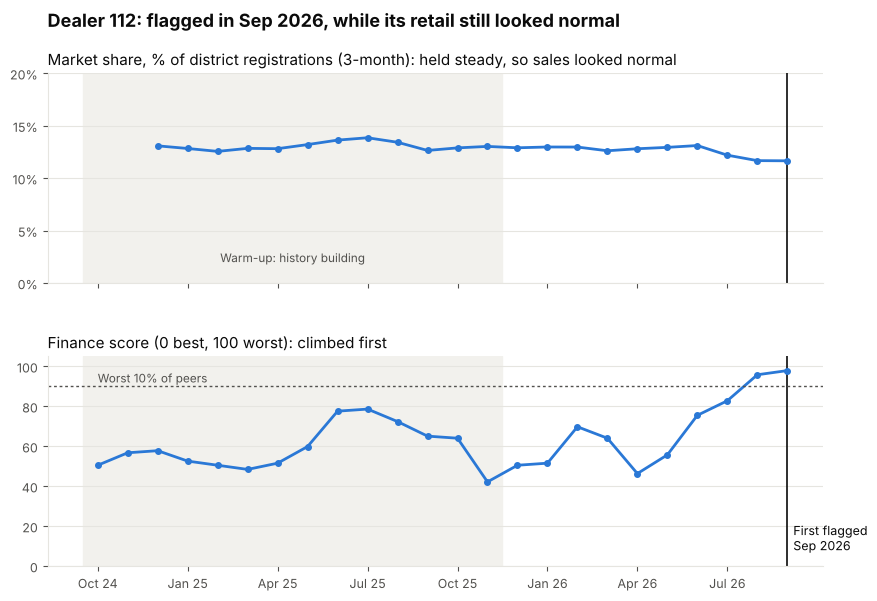

First flagged Sep 2026 as 'Cash stress ahead of a sales fall'. Retail in the final three months: 160, 160, 160 a month.


In [11]:
h = df[df.dealer_id == D112].sort_values("month_index").reset_index(drop=True)
first_flag = int(h.loc[h.needs_visit, "month_index"].min())
fell = h.loc[(h.month_index >= first_flag) & (h.d_share_trend < -.10), "month_index"]
share_fell = int(fell.min()) if len(fell) else None
label = lambda t: pd.Period(MONTHS[t]).strftime("%b %Y")

INK, MUTED, GRID, BLUE = "#0b0b0b", "#52514e", "#e6e5e0", "#2a78d6"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1], "hspace": .35})
fig.patch.set_facecolor("white")
for ax in (ax1, ax2):
    ax.axvspan(-.5, P["warm_up_months"] - .5, color="#f2f1ed", zorder=0)
    ax.grid(axis="y", color=GRID, linewidth=.8); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.axvline(first_flag, color=INK, linewidth=1.2)
    if share_fell is not None:
        ax.axvline(share_fell, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)))

share3 = h["_retail_units_3m"] / h["_district_registrations_3m"] * 100   # removes the festive cycle
ax1.plot(h.month_index, share3, color=BLUE, linewidth=2, marker="o", markersize=4)
ax1.set_ylim(0, 20); ax1.set_yticks(range(0, 21, 5), [f"{v}%" for v in range(0, 21, 5)])
ax1.set_title("Market share, % of district registrations (3-month): held steady, so sales looked normal",
              loc="left", fontsize=11, color=INK)
ax1.text(P["warm_up_months"]/2 - .5, 2, "Warm-up: history building", ha="center", fontsize=8.5, color=MUTED)

ax2.plot(h.month_index, h.B_finance, color=BLUE, linewidth=2, marker="o", markersize=4)
ax2.axhline(100 - TIER1, color=MUTED, linewidth=1, linestyle=(0, (2, 2)))
ax2.text(0, 100 - TIER1 + 2, f"Worst {TIER1}% of peers", fontsize=8.5, color=MUTED)
ax2.set_ylim(0, 105)
ax2.set_title("Finance score (0 best, 100 worst): climbed first", loc="left", fontsize=11, color=INK)
ax2.text(first_flag + .2, 8, f"First flagged\n{label(first_flag)}", fontsize=9, color=INK)
if share_fell is not None:
    ax2.text(share_fell + .2, 8, f"Share 10% below\nlast year, {label(share_fell)}", fontsize=9, color=MUTED)

ticks = list(range(0, N_MONTHS, 3))
ax2.set_xticks(ticks, [pd.Period(MONTHS[t]).strftime("%b %y") for t in ticks])
lead = (share_fell - first_flag) if share_fell is not None else None
fig.suptitle(f"Dealer 112: flagged {lead} months before its market share fell" if lead
             else f"Dealer 112: flagged in {label(first_flag)}, while its retail still looked normal",
             x=.125, ha="left", fontsize=13, fontweight="bold", color=INK)
plt.show()
print(f"First flagged {label(first_flag)} as '{h.loc[h.month_index == first_flag, 'cause'].iloc[0]}'. "
      + (f"Share fell 10% below last year in {label(share_fell)}: {lead} months later." if lead else
         f"Retail in the final three months: {', '.join(str(v) for v in h.retail_units.tail(3))} a month."))

## 8. Does it work?

A prototype that flags everyone is useless, and so is one that flags nobody. The dataset has six
planted behaviours the engine never sees, so five things can be measured on the live months
(month 14 onward):

1. **Recall:** of the dealers that really have a problem, how many are on a visit list.
2. **False flags:** healthy and market-limited dealers sent for a visit. Market-limited dealers are
   the hard case: their sales fall because their market falls faster, so they should be left alone.
3. **Precision of each manager's list:** the measure that matters operationally. A list with false
   alarms at the top gets ignored, and then nothing else matters.
4. **Lead time:** months between the first flag and the planted sales fall. A flag *before* the
   problem was planted is a false alarm, not foresight, so it is not counted. Month 14 is the first
   live month, so a catch there may have been possible earlier.
5. **Diagnosis accuracy:** whether the named cause matches the planted one.

In [12]:
truth = master.set_index("dealer_id").truth
PROBLEMS = ["silent_sinker_cash", "silent_sinker_push", "silent_sinker_margin",
            "silent_sinker_brand", "execution_gap"]
EXPECTED = {"silent_sinker_cash": "cash_stress", "silent_sinker_push": "stock_pushed",
            "silent_sinker_margin": "margin_bleed", "silent_sinker_brand": "brand_damage",
            "execution_gap": "execution_gap"}
# Planted onset and sales fall, read off the generator in section 2 (the engine never sees these)
ONSET = {"silent_sinker_cash": 12, "silent_sinker_push": 10, "silent_sinker_margin": 11,
         "silent_sinker_brand": 11, "execution_gap": 12}
SALES_FALL = {"silent_sinker_cash": 18, "silent_sinker_push": 19, "silent_sinker_brand": 18,
              "execution_gap": 15}           # margin bleed buys volume: its sales do not fall
SHIFT = {D112: D112_SHIFT}                   # Dealer 112's stress starts 7 months later

live = df[df.month_index >= P["warm_up_months"]].copy()
live["truth"] = live.dealer_id.map(truth)
fin = live[live.month_index == last_t]
prob = fin.truth.isin(PROBLEMS)

print(f"FINAL MONTH ({MONTHS[last_t]})\n")
print(pd.crosstab(fin.truth, fin.route).to_string())
print(f"\nRecall on planted problems : {fin.needs_visit[prob].mean():.0%}"
      f"  ({fin.needs_visit[prob].sum()} of {prob.sum()})")
print(f"False flags                : {fin.needs_visit[~prob].mean():.0%}"
      f"  ({fin.needs_visit[~prob].sum()} of {(~prob).sum()} healthy or market-limited)")

lists = fin[fin.on_list]
print(f"\nEACH MANAGER'S LIST (capacity {P['manager_capacity']})")
for region, grp in lists.groupby("region"):
    ok = grp.truth.isin(PROBLEMS).sum()
    print(f"  {region}: {ok} of {len(grp)} are genuine planted problems")
display(lists.sort_values(["region", "rank"])[["region", "rank", "dealer_name", "archetype", "rule",
                                               "truth"]].astype({"rank": int}).set_index(["region", "rank"]))

hl = live[live.truth == "healthy"]
print(f"ACROSS ALL {live.month_index.nunique()} LIVE MONTHS: healthy dealer-months sent for a visit "
      f"{hl.needs_visit.mean():.0%} ({hl.needs_visit.sum()} of {len(hl)}); healthy dealers flagged at "
      f"least once: {hl[hl.needs_visit].dealer_id.nunique()} of {hl.dealer_id.nunique()}")

rows = []
for d, t in truth.items():
    fall = SALES_FALL.get(t, 99) + SHIFT.get(d, 0)
    if fall <= last_t:                          # only dealers whose sales fall inside the window
        onset = ONSET[t] + SHIFT.get(d, 0)
        hit = live[(live.dealer_id == d) & (live.month_index >= onset) & live.needs_visit]
        f = int(hit.month_index.min()) if len(hit) else None
        rows.append(dict(truth=t, dealer=d, onset=onset, first_flag=f, sales_fall=fall,
                         lead_months=(fall - f) if f is not None else None))
lt = pd.DataFrame(rows)
print("\nLEAD TIME: months from first flag to the planted sales fall")
print(lt.groupby("truth").agg(dealers=("dealer", "count"), caught=("first_flag", "count"),
                              median_lead=("lead_months", "median")).to_string())
print(f"Overall median lead: {lt.lead_months.median():.0f} months before the sales fall")

cp = fin[prob & fin.needs_visit]
acc = (cp.rule == cp.truth.map(EXPECTED)).mean()
print(f"\nDIAGNOSIS: named cause matches the planted one for {acc:.0%} of caught problems "
      f"({(cp.rule == cp.truth.map(EXPECTED)).sum()} of {len(cp)})")
print(pd.crosstab(cp.truth, cp.rule).to_string())

FINAL MONTH (2026-09)

route                 No action: benchmark  No action: monitor  Regional manager visit  Sales planning: target reset
truth                                                                                                               
execution_gap                            0                   0                       4                             0
healthy                                 14                  11                       0                             0
market_limited                           0                   0                       0                             5
silent_sinker_brand                      0                   1                       2                             0
silent_sinker_cash                       0                   0                       4                             0
silent_sinker_margin                     0                   2                       1                             0
silent_sinker_push                       

dealer_name          archetype           rule                truth
region rank                                                                                   
East   1                Nagpur Motors 2      Silent sinker   stock_pushed   silent_sinker_push
       2               Jalgaon Motors 2      Silent sinker   brand_damage  silent_sinker_brand
       3            Chandrapur Motors 2      Silent sinker   stock_pushed   silent_sinker_push
       4                Nanded Motors 3      Silent sinker   stock_pushed   silent_sinker_push
West   1                  Pune Motors 1  Visible struggler  execution_gap        execution_gap
       2                  Pune Motors 2      Silent sinker   stock_pushed   silent_sinker_push
       3     Nashik Motors (Dealer 112)      Silent sinker    cash_stress   silent_sinker_cash
       4                Nashik Motors 1      Silent sinker    cash_stress   silent_sinker_cash

ACROSS ALL 10 LIVE MONTHS: healthy dealer-months sent for a visit 6% (14 of 250); healthy dealers flagged at least once: 6 of 25

LEAD TIME: months from first flag to the planted sales fall
                     dealers  caught  median_lead
truth                                            
execution_gap              4       4         0.00
silent_sinker_brand        3       3         1.00
silent_sinker_cash         3       3         2.00
silent_sinker_push         4       4         5.00
Overall median lead: 2 months before the sales fall

DIAGNOSIS: named cause matches the planted one for 100% of caught problems (15 of 15)
rule                  brand_damage  cash_stress  execution_gap  margin_bleed  stock_pushed
truth                                                                                     
execution_gap                    0            0              4             0             0
silent_sinker_brand              2            0              0             0             0
silent_

### The cutoff is a dial the client sets

The 10% cutoff is not asserted. The sweep below reruns the **whole engine** (signals, diagnosis,
routing) at every cutoff from 2% to 30%, and shows how many dealers get flagged against what the
managers can act on. The client picks the point; this curve is the calibration. With cohorts of
about 16 dealers, percentiles move in steps of about 6, so neighbouring cutoffs can give the same
result.

2 regional managers x capacity 4 = 8 visits a month

 worst_pct_cutoff  flagged recall false_flags
                2       12    67%          0%
                3       12    67%          0%
                4       12    67%          0%
                5       12    67%          0%
                6       12    67%          0%
                7       13    72%          0%
                8       13    72%          0%
                9       15    83%          0%
               10       15    83%          0%
               11       15    83%          0%
               12       15    83%          0%
               13       16    83%          3%
               14       16    83%          3%
               15       16    83%          3%
               16       17    89%          3%
               17       19    89%         10%
               18       19    89%         10%
               19       20    89%         13%
               20       20    89%         13%
               21       22 

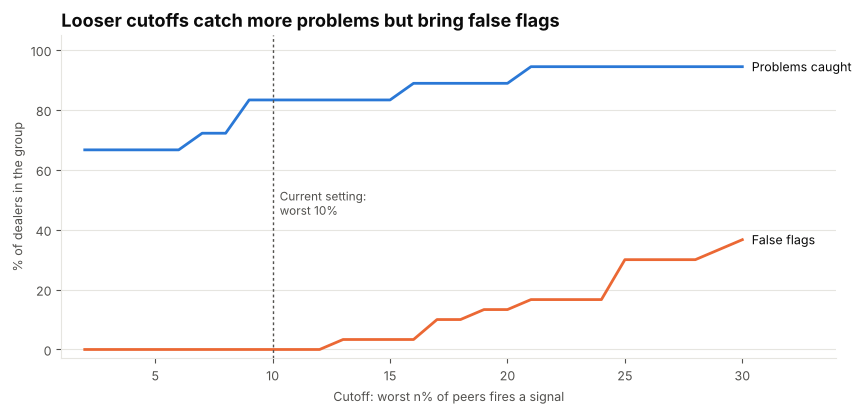

Current setting, worst 10%: 15 flagged for 8 visits, recall 83%, false flags 0%. Tighter means fewer false alarms and more missed dealers; the client moves this dial.


In [13]:
TARGET = P["manager_capacity"] * df.region.nunique()
rows = []
for c in range(2, 31):
    x = decide(df, c)
    f = x[x.month_index == last_t]
    p_ = f.dealer_id.map(truth).isin(PROBLEMS)
    rows.append((c, int(f.needs_visit.sum()), f.needs_visit[p_].mean(), f.needs_visit[~p_].mean()))
sweep = pd.DataFrame(rows, columns=["worst_pct_cutoff", "flagged", "recall", "false_flags"])
print(f"{df.region.nunique()} regional managers x capacity {P['manager_capacity']} = {TARGET} visits a month\n")
print(sweep.to_string(index=False, formatters={"recall": "{:.0%}".format, "false_flags": "{:.0%}".format}))

fig, ax = plt.subplots(figsize=(10, 4.2))
fig.patch.set_facecolor("white")
ax.plot(sweep.worst_pct_cutoff, sweep.recall * 100, color="#2a78d6", linewidth=2)
ax.plot(sweep.worst_pct_cutoff, sweep.false_flags * 100, color="#eb6834", linewidth=2)
end = sweep.iloc[-1]
ax.text(end.worst_pct_cutoff + .4, end.recall * 100, "Problems caught", va="center", fontsize=9, color=INK)
ax.text(end.worst_pct_cutoff + .4, end.false_flags * 100, "False flags", va="center", fontsize=9, color=INK)
ax.axvline(TIER1, color=MUTED, linewidth=1, linestyle=(0, (2, 2)))
ax.text(TIER1 + .3, 45, f"Current setting:\nworst {TIER1}%", fontsize=8.5, color=MUTED)
ax.set_xlim(1, 34); ax.set_ylim(-3, 105)
ax.set_xlabel("Cutoff: worst n% of peers fires a signal", color=MUTED, fontsize=9)
ax.set_ylabel("% of dealers in the group", color=MUTED, fontsize=9)
ax.grid(axis="y", color=GRID, linewidth=.8); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
ax.set_title("Looser cutoffs catch more problems but bring false flags", loc="left",
             fontsize=13, fontweight="bold", color=INK)
plt.show()
cur = sweep[sweep.worst_pct_cutoff == TIER1].iloc[0]
print(f"Current setting, worst {TIER1}%: {cur.flagged:.0f} flagged for {TARGET} visits, recall "
      f"{cur.recall:.0%}, false flags {cur.false_flags:.0%}. Tighter means fewer false alarms and "
      f"more missed dealers; the client moves this dial.")

## 9. Feedback loop

Dealers flagged at the extreme drift back toward average on their own, so **every action would
look like it worked.** The control group is the fix: dealers that were diagnosed but fell just below
their manager's capacity cut, so they were not visited. They are similar and untreated, which gives
a free comparison.

No action is simulated in this prototype, so both groups only drift. That makes this a **placebo
check**: the gap between the groups is the noise a real intervention would have to beat. If risk
does not fall against the control after a real action, the next question is whether the flag was
wrong (retune the thresholds) or the action was wrong (change the action table).

In [14]:
CYCLE = P["review_cycle_months"]
base_m, rev_m = last_t - CYCLE, last_t
base = df[(df.month_index == base_m) & df.needs_visit]
treated = base[base.on_list].dealer_id.tolist()                                  # visited
control = base[(base["rank"] > P["manager_capacity"])
               & (base["rank"] <= 2 * P["manager_capacity"])].dealer_id.tolist()  # just below the cut
risk_at = lambda m_: df[df.month_index == m_].set_index("dealer_id").risk_score
rb, rr = risk_at(base_m), risk_at(rev_m)
res = pd.DataFrame({
    "group": ["Diagnosed and visited", "Diagnosed, not visited (control)"],
    "dealers": [len(treated), len(control)],
    f"risk {MONTHS[base_m]}": [rb[treated].mean(), rb[control].mean()],
    f"risk {MONTHS[rev_m]}":  [rr[treated].mean(), rr[control].mean()],
})
res["change"] = res.iloc[:, 3] - res.iloc[:, 2]
print(f"Review after {CYCLE} months\n"); print(res.to_string(index=False))
print(f"\nGap between the groups with no action taken: {res.change.iloc[0] - res.change.iloc[1]:+.1f} "
      "risk points. A real intervention has to beat this noise before anyone calls it a success.")

Review after 3 months

                           group  dealers  risk 2026-06  risk 2026-09  change
           Diagnosed and visited        8         70.59         73.23    2.64
Diagnosed, not visited (control)        7         71.73         71.33   -0.40

Gap between the groups with no action taken: +3.0 risk points. A real intervention has to beat this noise before anyone calls it a success.


## 10. What this prototype does not do

| Limit | Why it matters | Handling |
|---|---|---|
| **Association, not cause** | The engine cannot know why a dealer is failing | It decides *where* the manager goes. The manager confirms *why* on the ground. |
| **Finance and inventory values are representative** | Not the client's real ledger | Schema, grain and source systems are real. In an engagement the extract is replaced by a data pull and the logic does not change. |
| **Value at stake is illustrative** | Contribution per car and buyers lost are placeholders | Shown as a 25% to 75% range; the ranking does not depend on the share. Q8 supplies both. |
| **Weights are illustrative** | 35/25/25/15 is reasoned, not fitted | Q2 supplies the lost-dealer record and the weights are refitted on it. |
| **Peer ranking misses a region falling together** | Nobody's percentile moves | The three contractual hard floors are absolute and still fire. |
| **Small network** | Fine cohorts fall below the minimum size | The demo ranks within market band; a full network supports the four-part cohort. |
| **No action is simulated** | Section 9 shows drift, not effect | The control-group design is what is demonstrated, as a placebo check. |
| **Google reviews not wired in** | Rural outlets have too few reviews to score | The customer bucket runs on internal data; Google is a cross-check above a minimum review count. |

**The honest summary:** the mechanism is ours and it runs today. The numbers are the client's, and
ten questions get them. Until those are answered, every threshold on screen is a placeholder,
labelled as one.

## 11. Hand-off

Five files, ready for Power BI or Excel:

- `manager_lists.csv`: this month's visit list for each regional manager, plus the dealers routed to
  sales planning and network development.
- `dealer_scores.csv`: one row per dealer per month with the decision on it.
- `signals_long.csv`: the audit trail. Every metric, every month, its score and whether it fired.
- `parameter_register.csv` and `field_sources.csv`: the two accountability tables, one for every
  number and one for every field.

In [15]:
out_cols = ["dealer_id", "dealer_name", "district", "region", "market_band", "outlet_type", "cohort",
            "month", "month_index", "retail_units", "target_units", "target_achievement",
            "district_registrations", *[f"B_{b}" for b in BUCKETS], "risk_score", "value_at_stake",
            "value_at_stake_25", "value_at_stake_75", "signals", "floors_breached", "tier", "priority",
            "rank", "on_list", "archetype", "cause", "also_fired", "action", "owner", "route",
            "needs_visit"]
scores = df[out_cols].round(3)
lists_out = df[(df.month_index == last_t) & (df.on_list | df.archetype.isin(["Market limited", "Underleveraged"]))][
    ["region", "rank", "dealer_id", "dealer_name", "district", "archetype", "tier", "risk_score",
     "value_at_stake", "cause", "also_fired", "action", "owner", "route"]].sort_values(
    ["route", "region", "rank"]).round(1)
sig_long = pd.concat([
    df[["dealer_id", "month", "month_index"]].assign(
        metric=m, bucket=BUCKET_OF[m], metric_score=df[f"M_{m}"].round(1),
        worse_than_last_window=df[f"UP_{m}"],
        signal_confirmed=df[f"S_{m}"] if f"S_{m}" in df else False) for m in SCORED])
files = [("manager_lists.csv", lists_out), ("dealer_scores.csv", scores), ("signals_long.csv", sig_long),
         ("parameter_register.csv", register), ("field_sources.csv", schema)]
for f, d in files:
    d.to_csv(f, index=False)
print("Written:")
for f, d in files:
    print(f"  {f:24s} {d.shape[0]:>6,} rows x {d.shape[1]:>2} cols")

Written:
  manager_lists.csv            13 rows x 14 cols
  dealer_scores.csv         1,152 rows x 34 cols
  signals_long.csv         18,432 rows x  8 cols
  parameter_register.csv       25 rows x  4 cols
  field_sources.csv            27 rows x  4 cols
